# Demo Pruning

## Setup

In [21]:
print('Installing torchprofile...')
!pip install torchprofile 1>/dev/null
print('All required packages have been successfully installed!')

Installing torchprofile...
All required packages have been successfully installed!


In [22]:
import copy
import math
import random
import time
from collections import OrderedDict, defaultdict
from typing import Union, List
from matplotlib import pyplot as plt

import numpy as np
import torch
from torch import nn
from torch.optim import *
from torch.optim.lr_scheduler import *
from torch.utils.data import DataLoader

from torchvision.datasets import *
from torchvision.transforms import *

from tqdm.auto import tqdm

from torchprofile import profile_macs

import torch.nn.functional as F


assert torch.cuda.is_available(), \
"The current runtime does not have CUDA support." \
"Please go to menu bar (Runtime - Change runtime type) and select GPU"

In [23]:
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

In [24]:
def train(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    optimizer: Optimizer,
    scheduler: StepLR,
    callbacks = None
) -> None:

  model.train()

  for inputs, targets in tqdm(dataloader, desc='train', leave=False):

    # Move the data from CPU to GPU
    inputs = inputs.cuda()
    targets = targets.cuda()

    # Reset the gradients (from the last iteration)
    optimizer.zero_grad()

    # Forward inference
    outputs = model(inputs)
    loss = criterion(outputs, targets)

    # Backward propagation
    loss.backward()

    # Update optimizer
    optimizer.step()

    if callbacks is not None:
      for callback in callbacks:
        callback()

  # Update scheduler
  scheduler.step()

In [25]:
@torch.inference_mode()
def evaluate(
    model: nn.Module,
    dataloader: DataLoader,
    verbose=True
) -> float:

  model.eval()

  num_samples = 0
  num_correct = 0

  for inputs, targets in tqdm(dataloader, desc='eval', leave=False, disable=not verbose):

    # Move the data from CPU to GPU
    inputs = inputs.cuda()
    targets = targets.cuda()

    # Inference
    outputs = model(inputs)

    # Convert logits to class indices
    outputs = outputs.argmax(dim=1)

    # Update metrics
    num_samples += targets.size(0)
    num_correct += (outputs == targets).sum()

  return (num_correct / num_samples * 100).item()

### Helper Functions (FLOPS, Model Size Calcuation, etc.)

In [26]:
def get_model_macs(model, inputs) -> int:
  return profile_macs(model, inputs)

In [27]:
def get_sparsity(tensor: torch.Tensor) -> float:
  """
  Calculate the sparsity of the given tensor

  sparsity = zeros / elements = 1 - nonzeros / elements)
  """
  return 1 - float(tensor.count_nonzero()) / tensor.numel()

In [28]:
def get_model_sparsity(model: nn.Module) -> float:
  """
  Calculate the sparsity of the given model

  sparsity = zeros / elements = 1 - (nonzeros / elements)
  """
  num_nonzeros, num_elements = 0, 0
  for param in model.parameters():
    num_nonzeros += param.count_nonzero()
    num_elements += param.numel()
  return 1 - float(num_nonzeros) / num_elements

In [29]:
def get_num_parameters(model: nn.Module, count_nonzero_only=False) -> int:
  """
  Calculate the total number of parameters of model
    param - count_nonzero_only: only count nonzero weights
  """
  num_counted_elements = 0
  for param in model.parameters():
    if count_nonzero_only:
      num_counted_elements += param.count_nonzero()
    else:
      num_counted_elements += param.numel()
  return num_counted_elements

In [30]:
def get_model_size(model: nn.Module, data_width=32, count_nonzero_only=False) -> int:
  """
  Calculate the model size in bits
    param - data_width: bits per element
    param - count_nonzero_only: only count nonzero weights
  """
  return get_num_parameters(model, count_nonzero_only) * data_width

In [31]:
Byte = 8
KiB = 1024 * Byte
MiB = 1024 * KiB
GiB = 1024 * MiB

### Define Pruning Functions

In [32]:
def fine_grained_prune(
    tensor: torch.Tensor,
    sparsity: float
) -> torch.Tensor:
  """
  magnitude-based pruning for single tensor
    param - tensor: torch.(.cuda)Tensor, weight of conv/fc layer
    param - sparsity: float, pruning sparsity

    sparsity = zeros / elements = 1 - nonzeros / elements

    return - torch.(.cuda)Tensor, mask for zeros
  """
  sparsity = min(max(0.0, sparsity), 1.0)
  if sparsity == 1.0:
    tensor.zero_()
    return torch.zeros_like(tensor)
  elif sparsity == 0.0:
    return torch.ones_like(tensor)

  num_elements = tensor.numel()

  num_zeros = round(num_elements * sparsity)
  importance = tensor.abs()
  threshold = importance.view(-1).kthvalue(num_zeros).values

  mask = torch.gt(importance, threshold)
  tensor.mul_(mask)

  return mask

In [33]:
class FineGrainedPruner:

  def __init__(self, model, sparsity_dict):
    self.masks = FineGrainedPruner.prune(model, sparsity_dict)

  @torch.no_grad()
  def apply(self, model):
    for name, param in model.named_parameters():
      if name in self.masks:
        param *= self.masks[name]

  @staticmethod
  @torch.no_grad()
  def prune(model, sparsity_dict):
    masks = dict()
    for name, param in model.named_parameters():
      if param.dim() > 1: # we only prune conv and fc weights
        if isinstance(sparsity_dict, dict):
          masks[name] = fine_grained_prune(param, sparsity_dict[name])
        else:
          assert(sparsity_dict < 1 and sparsity_dict >= 0)
          if sparsity_dict > 0:
            masks[name] = fine_grained_prune(param, sparsity_dict)

    return masks

### Load the MNIST dataset

In [34]:
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
    ])
to_image = lambda t: (t*0.3081+0.1307).squeeze(0).to('cpu').numpy()

dataset = {}
for split in ["train", "test"]:
  dataset[split] = MNIST(
    "data",
    train=(split == "train"),
    download=(split == "train"),
    transform=transform,
  )

dataloader = {}
for split in ['train', 'test']:
  dataloader[split] = DataLoader(
    dataset[split],
    batch_size=256 if split == 'train' else 1000,
    shuffle=(split == 'train'),
    num_workers=0,
    pin_memory=True
  )

### Create a set of test images for demo

In [35]:
demos = {0: 3, 1: 2, 2: 1, 3: 30, 4: 4, 5: 15, 6: 11, 7: 0, 8: 61, 9: 9}

demo_inputs, demo_images = [], []
for digit, index in demos.items():
    demo_inputs.append(copy.deepcopy(dataset['test'][index][0]))
    demo_images.append(to_image(demo_inputs[-1]))
demo_inputs = torch.stack(demo_inputs).cuda()

## Neural Network Model

In [36]:
class Net(nn.Module):

  def __init__(self):
    super(Net, self).__init__()
    self.conv1 = nn.Conv2d(1, 32, 3, 1) # 1 x 32 x 3 x 3 = 288 parameters
    self.conv2 = nn.Conv2d(32, 64, 3, 1) # 32 x 64 x 3 x 3 = 18,432 parameters
    self.dropout1 = nn.Dropout(0.25)
    self.dropout2 = nn.Dropout(0.5)
    self.fc1 = nn.Linear(9216, 128) # 9216 x 128 = 1,179,648 parameters
    self.fc2 = nn.Linear(128, 10) # 128 x 10 = 1,280 parameters

  def forward(self, x):
    x = self.conv1(x)
    x = F.relu(x)
    x = self.conv2(x)
    x = F.relu(x)
    x = F.max_pool2d(x, 2)
    x = self.dropout1(x)
    x = torch.flatten(x, 1)
    x = self.fc1(x)
    x = F.relu(x)
    x = self.dropout2(x)
    x = self.fc2(x)
    output = F.log_softmax(x, dim=1)
    return output

In [37]:
model = Net().cuda()

## Let's visualize the Demo Images

In [38]:
def visualize(with_predictions=False):
  plt.figure(figsize=(20, 10))
  predictions = model(demo_inputs).argmax(dim=1) if with_predictions else None
  for digit, index in demos.items():
    plt.subplot(1, 10, digit + 1)
    plt.imshow(demo_images[digit])
    if predictions is None:
        plt.title(f"digit: {digit}")
    else:
        plt.title(f"digit: {digit}\npred: {int(predictions[digit])}")
    plt.axis('off')
  plt.show()

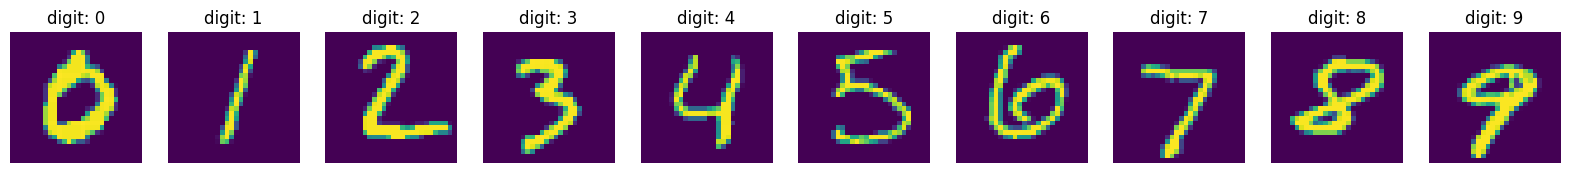

In [39]:
visualize()

## Pre-train Neural Network on MNIST

In [40]:
lr = 1.0
lr_step_gamma = 0.7
num_epochs = 5

optimizer = Adadelta(model.parameters(), lr=lr)
criterion = F.nll_loss
scheduler = StepLR(optimizer, step_size=1, gamma=lr_step_gamma)

best_accuracy = 0
best_checkpoint = dict()

for epoch in range(num_epochs):
  train(model, dataloader['train'], criterion, optimizer, scheduler)
  accuracy = evaluate(model, dataloader['test'])
  is_best = accuracy > best_accuracy
  if is_best:
    best_checkpoint['state_dict'] = copy.deepcopy(model.state_dict())
    best_accuracy = accuracy
  print(f'    Epoch {epoch+1:>2d} Accuracy {accuracy:.2f}% / Best Accuracy: {best_accuracy:.2f}%')

print(f"=> loading best checkpoint")
model.load_state_dict(best_checkpoint['state_dict'])
recovery_model = lambda: model.load_state_dict(best_checkpoint['state_dict'])

train:   0%|          | 0/235 [00:00<?, ?it/s]

eval:   0%|          | 0/10 [00:00<?, ?it/s]

    Epoch  1 Accuracy 98.13% / Best Accuracy: 98.13%


train:   0%|          | 0/235 [00:00<?, ?it/s]

eval:   0%|          | 0/10 [00:00<?, ?it/s]

...

eval:   0%|          | 0/10 [00:00<?, ?it/s]

    Epoch  4 Accuracy 98.93% / Best Accuracy: 98.93%


train:   0%|          | 0/235 [00:00<?, ?it/s]

eval:   0%|          | 0/10 [00:00<?, ?it/s]

    Epoch  5 Accuracy 98.97% / Best Accuracy: 98.97%
=> loading best checkpoint


## Let's First Evaluate the Accuracy and Model Size of Dense Model

Let's first evaluate the accuracy and model size of this model.

eval:   0%|          | 0/10 [00:00<?, ?it/s]

dense model has accuracy=98.97%
dense model has size=4.58 MiB


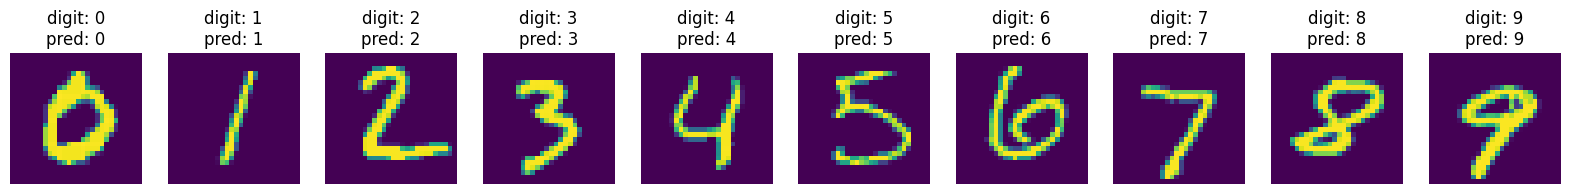

In [41]:
dense_model_accuracy = evaluate(model, dataloader['test'])
dense_model_size = get_model_size(model)
print(f"dense model has accuracy={dense_model_accuracy:.2f}%")
print(f"dense model has size={dense_model_size/MiB:.2f} MiB")
visualize(True)

## Let's Prune the Model and Re-Evaluate the Accuracy

eval:   0%|          | 0/10 [00:00<?, ?it/s]

70.0% sparse model has accuracy=96.18%
70.0% sparse model has size=1.37 MiB, which is 3.33X smaller than the 4.58 MiB dense model


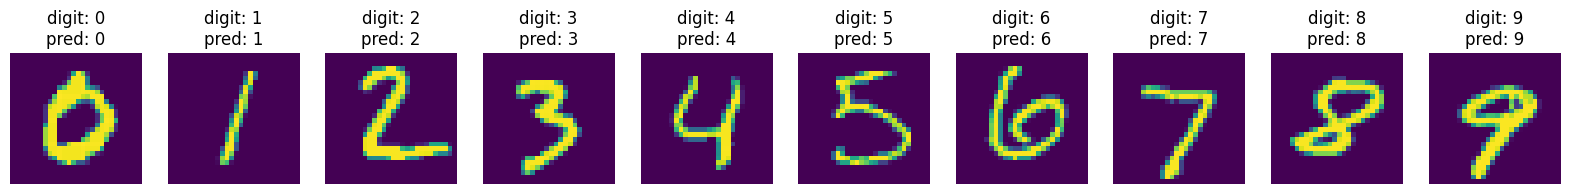

In [42]:
sparsity = 0.7
recovery_model()

pruner = FineGrainedPruner(model, sparsity)
pruner.apply(model)

sparse_model_accuracy = evaluate(model, dataloader['test'])
sparse_model_size = get_model_size(model, count_nonzero_only=True)
print(f"{sparsity*100}% sparse model has accuracy={sparse_model_accuracy:.2f}%")
print(f"{sparsity*100}% sparse model has size={sparse_model_size/MiB:.2f} MiB, "
      f"which is {dense_model_size/sparse_model_size:.2f}X smaller than "
      f"the {dense_model_size/MiB:.2f} MiB dense model")
visualize(True)

## Let's Fine-tune the Pruned Model to Get Higher AccuracY

In [43]:
num_finetune_epochs = 2
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    num_finetune_epochs
)

In [44]:
best_sparse_checkpoint = dict()
best_sparse_accuracy = 0

In [45]:
print(f'Finetuning Fine-grained Pruned Sparse Model')
for epoch in range(num_finetune_epochs):
  # At the end of each train iteration, we have to apply the pruning mask
  #    to keep the model sparse during the training
  train(model, dataloader['train'], criterion, optimizer, scheduler, callbacks=[lambda: pruner.apply(model)])
  accuracy = evaluate(model, dataloader['test'])

  is_best = accuracy > best_sparse_accuracy
  if is_best:
    best_sparse_checkpoint['state_dict'] = copy.deepcopy(model.state_dict())
    best_sparse_accuracy = accuracy
  print(f'    Epoch {epoch+1} Sparse Accuracy {accuracy:.2f}% / Best Sparse Accuracy: {best_sparse_accuracy:.2f}%')

Finetuning Fine-grained Pruned Sparse Model


train:   0%|          | 0/235 [00:00<?, ?it/s]

eval:   0%|          | 0/10 [00:00<?, ?it/s]

    Epoch 1 Sparse Accuracy 98.75% / Best Sparse Accuracy: 98.75%


train:   0%|          | 0/235 [00:00<?, ?it/s]

eval:   0%|          | 0/10 [00:00<?, ?it/s]

    Epoch 2 Sparse Accuracy 98.96% / Best Sparse Accuracy: 98.96%


eval:   0%|          | 0/10 [00:00<?, ?it/s]

70.0% sparse model has accuracy=98.96%
70.0% sparse model has size=1.37 MiB, which is 3.33X smaller than the 4.58 MiB dense model


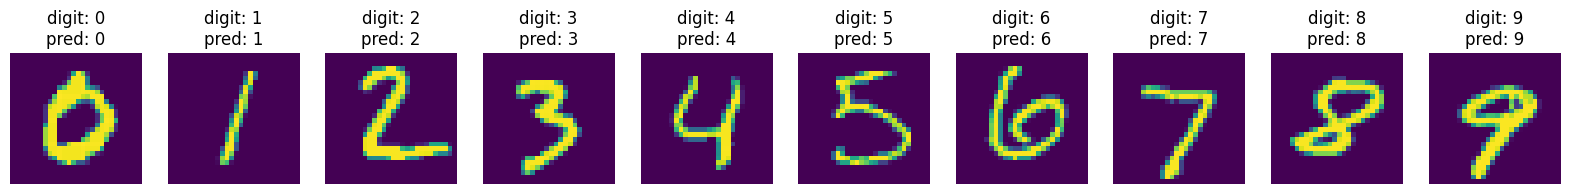

In [46]:
model.load_state_dict(best_sparse_checkpoint['state_dict'])
sparse_model_accuracy = evaluate(model, dataloader['test'])
sparse_model_size = get_model_size(model, count_nonzero_only=True)
print(f"{sparsity*100}% sparse model has accuracy={sparse_model_accuracy:.2f}%")
print(f"{sparsity*100}% sparse model has size={sparse_model_size/MiB:.2f} MiB, "
      f"which is {dense_model_size/sparse_model_size:.2f}X smaller than "
      f"the {dense_model_size/MiB:.2f} MiB dense model")
visualize(True)